# EDA Lab 1: Data Exploration & Visualization

##### In this lab, we will be going over some basic data analysis techniques like feature selection, finding the correlation between different features and visualizing our data to understand it better.


##### Domain knowledge: The lab does not require any domain knowledge of basketball or what the column names stand for. In fact, it assumes you do not have any knowledge about basketball stats. However, you will see how domain knowledge helps as you progress forward.

Outcomes:
- Find “interesting” features about data from looking at tables and statistics about the data.
- Describe how visualization can be used as a data exploration tool and for verification purposes.
- Create some useful types of visualization

#### Importing libraries and loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##
#Loading playoffs data
df = pd.read_csv('raptors_games.csv')

#Setting up notebook so that all columns are displayed
pd.set_option('display.max_columns', None)

##### Observing data

In [2]:
df.head(7)

,TEAM,GDATE,MATCHUP,Result,MIN,POINTS,FGM,FGA,FG%,3PM,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,PF,+/-
0,TOR,1/13/2019,TOR @ WAS,W,290,140,49,104,47.1,13,36,36.1,29,36,80.6,17,42,59,24,16,8,21,27,2
1,TOR,11/29/2018,TOR vs. GSW,W,265,131,47,90,52.2,15,38,39.5,22,24,91.7,7,30,37,25,5,6,14,23,3
2,TOR,2/13/2019,TOR vs. WAS,W,241,129,44,92,47.8,16,38,42.1,25,30,83.3,9,43,52,32,8,8,14,27,9
3,TOR,10/30/2018,TOR vs. PHI,W,240,129,47,92,51.1,11,27,40.7,24,28,85.7,9,34,43,29,13,6,15,26,17
4,TOR,3/18/2019,TOR vs. NYK,W,240,128,49,88,55.7,17,40,42.5,13,22,59.1,5,45,50,36,5,6,14,22,36
5,TOR,11/10/2018,TOR vs. NYK,W,239,128,42,79,53.2,14,35,40.0,30,40,75.0,12,34,46,24,8,4,15,20,16
6,TOR,3/8/2019,TOR @ NOP,W,240,127,53,99,53.5,13,37,35.1,8,9,88.9,7,44,51,31,10,12,16,14,23


In [3]:
# checking the shape i.e. the number of rows and columns of the dataframe
df.shape

(82, 24)

##### Checking data type for each column

In [4]:
# checking the data types for each column in the dataframe
df.dtypes

,0
TEAM,object
GDATE,object
MATCHUP,object
Result,object
MIN,int64
POINTS,int64
FGM,int64
FGA,int64
FG%,float64
3PM,int64


In [5]:
# checking to see if there are empty or null cells
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 24 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TEAM     82 non-null     object 
 1   GDATE    82 non-null     object 
 2   MATCHUP  82 non-null     object 
 3   Result   82 non-null     object 
 4   MIN      82 non-null     int64  
 5   POINTS   82 non-null     int64  
 6   FGM      82 non-null     int64  
 7   FGA      82 non-null     int64  
 8   FG%      82 non-null     float64
 9   3PM      82 non-null     int64  
 10  3PA      82 non-null     int64  
 11  3P%      82 non-null     float64
 12  FTM      82 non-null     int64  
 13  FTA      82 non-null     int64  
 14  FT%      82 non-null     float64
 15  OREB     82 non-null     int64  
 16  DREB     82 non-null     int64  
 17  REB      82 non-null     int64  
 18  AST      82 non-null     int64  
 19  STL      82 non-null     int64  
 20  BLK      82 non-null     int64  
 21  TOV      82 non-nu

### Lab Activity 1: Data Preprocessing

##### [Q] The `'Result'` column tells us whether the team won or lost the game. However, since the `'Result'` column is in `text(object)` format, we cannot perform proper statistical analysis. Thus, we need to change it, so $1$ represents a win and $0$ represents a loss.

In [6]:
#Hint: Changing the values of the column does not change the data type. You need to alter both, the values and the data type the column represents

# changing the values in the column: 1 represents a win(W) and 0 represents a loss (L)
df['Result'].replace('W', '1', inplace=True)
df['Result'].replace('L', '0', inplace=True)

In [7]:
# changing the data type for Result column from object to int64
df['Result'] = df['Result'].astype('int')


##### [Q] Check the data types again.

In [8]:
#checking the data type for Result column
df['Result'].dtypes


dtype('int64')

In [9]:
#checking the data type for all columns
df.dtypes

,0
TEAM,object
GDATE,object
MATCHUP,object
Result,int64
MIN,int64
POINTS,int64
FGM,int64
FGA,int64
FG%,float64
3PM,int64


In [10]:
#checking the Result column values has changed from "W" and "L" to "1" and "0".
df

,TEAM,GDATE,MATCHUP,Result,MIN,POINTS,FGM,FGA,FG%,3PM,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,PF,+/-
0,TOR,1/13/2019,TOR @ WAS,1,290,140,49,104,47.1,13,36,36.1,29,36,80.6,17,42,59,24,16,8,21,27,2
1,TOR,11/29/2018,TOR vs. GSW,1,265,131,47,90,52.2,15,38,39.5,22,24,91.7,7,30,37,25,5,6,14,23,3
2,TOR,2/13/2019,TOR vs. WAS,1,241,129,44,92,47.8,16,38,42.1,25,30,83.3,9,43,52,32,8,8,14,27,9
3,TOR,10/30/2018,TOR vs. PHI,1,240,129,47,92,51.1,11,27,40.7,24,28,85.7,9,34,43,29,13,6,15,26,17
4,TOR,3/18/2019,TOR vs. NYK,1,240,128,49,88,55.7,17,40,42.5,13,22,59.1,5,45,50,36,5,6,14,22,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,TOR,12/30/2018,TOR vs. CHI,1,239,95,34,92,37.0,9,33,27.3,18,20,90.0,17,35,52,17,5,8,11,15,6
78,TOR,11/20/2018,TOR @ ORL,1,240,93,39,87,44.8,9,34,26.5,6,8,75.0,6,37,43,23,7,5,16,19,2
79,TOR,1/31/2019,TOR vs. MIL,0,240,92,37,93,39.8,7,27,25.9,11,13,84.6,8,31,39,16,9,4,16,20,-13
80,TOR,12/28/2018,TOR @ ORL,0,240,87,28,95,29.5,12,34,35.3,19,24,79.2,14,27,41,18,4,10,11,21,-29


##### [Q] Convert `'GDATE'` column to [`datetime` format](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html).

In [11]:
# changing column GDATE to datetime format
df['GDATE'] = pd.to_datetime(df['GDATE'])

#confirming GDATE columnn is now in datetime format (displaying the first 5 rows)
df['GDATE'].head()

,GDATE
0,2019-01-13
1,2018-11-29
2,2019-02-13
3,2018-10-30
4,2019-03-18


##### [Q] Add a column `'DELTA'` with the delta time in days. That is, the number of days between matches.

In [12]:
# sorting the dataframe by GDATE in ascending order
df = df.sort_values(by='GDATE')

# calculating number of days between matches
df['DELTA'] = df['GDATE'].diff().dt.days

# displaying number of days between matches, only the first 5 rows
df[['GDATE', 'DELTA']].head()


,GDATE,DELTA
43,2018-10-17,NaN
49,2018-10-19,2.0
40,2018-10-20,1.0
8,2018-10-22,2.0
51,2018-10-24,2.0


In [13]:
# resetting the index after sorting
df = df.reset_index(drop=True)

# displaying number of days between matches with index reset
df[['GDATE', 'DELTA']].head()

,GDATE,DELTA
0,2018-10-17,NaN
1,2018-10-19,2.0
2,2018-10-20,1.0
3,2018-10-22,2.0
4,2018-10-24,2.0


In [15]:
# repacing NaN values with 0
df['DELTA'] = df['DELTA'].fillna(0).astype(int)

# displaying number of days between matches with index reset
df[['GDATE', 'DELTA']].head()

,GDATE,DELTA
0,2018-10-17,0
1,2018-10-19,2
2,2018-10-20,1
3,2018-10-22,2
4,2018-10-24,2


This dataset is now preprocessed and in a correct format.

### Lab Activity Two: Statistical Analysis & Visualizations

##### [Q] Scatter plots are a useful method to observe relationships between variables. Plot a scatter plot of `'FGM'` (Y-axis) vs `'POINTS'` (X-axis).

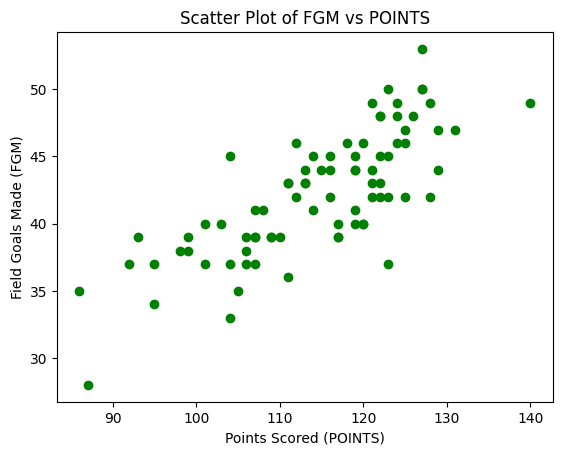

In [16]:
# importing library for making scatter plot
import matplotlib.pyplot as plt

# assigning POINTS column to x-axis and FGM columnn to y-axis
x = df['POINTS']
y = df['FGM']

# Creating a scatter plot using Matplotlib
plt.scatter(x, y, color = 'green')
plt.xlabel('Points Scored (POINTS)')
plt.ylabel('Field Goals Made (FGM)')
plt.title('Scatter Plot of FGM vs POINTS')
plt.show()


##### [Q] Describe the relationship between Field Goals Made (`'FGM'`) and Points Scored (`'POINTS'`). What can you observe?

**There exists a strong, positive linear correlation between FGM and POINTS. The strength of correlation is evidenced by the closely spaces data points and the upward trend shows the relationship is linear.**

##### [Q] Let's observe the [correlation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) between each column

In [17]:
#Make a new dataframe containing the correlations. Tip: The correlations of the features in your dataset can be simply obtained by using pandas_dataframe.corr()

# correlationg the numeric values in the dataframe
df_corr = df.corr(numeric_only=True)

#displaying the correlation matrix
df_corr

,Result,MIN,POINTS,FGM,FGA,FG%,3PM,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,PF,+/-,DELTA
Result,1.000000,-0.075488,0.575034,0.432612,-0.035753,0.386880,0.276205,0.000122,0.303570,0.212808,0.232450,-0.047695,-0.074823,0.340098,0.216745,0.376716,0.331385,0.107905,-0.103160,0.065232,0.775046,0.024431
MIN,-0.075488,1.000000,0.205407,0.047877,0.209642,-0.092809,0.038488,0.114129,-0.034957,0.281027,0.232236,0.105981,0.062474,0.137884,0.152323,-0.045692,0.177722,0.050830,0.208603,0.208197,-0.118805,-0.050148
POINTS,0.575034,0.205407,1.000000,0.772660,0.011150,0.671907,0.446822,0.083493,0.482326,0.358861,0.334081,0.122893,-0.122107,0.329554,0.175580,0.554875,0.192245,0.023599,0.045593,0.306924,0.638127,-0.074101
FGM,0.432612,0.047877,0.772660,1.000000,0.160288,0.769739,0.123228,-0.099486,0.197949,-0.218892,-0.217540,0.044170,-0.173898,0.367641,0.169707,0.566493,0.196000,0.059442,0.080031,0.118434,0.601160,-0.173268
FGA,-0.035753,0.209642,0.011150,0.160288,1.000000,-0.501263,-0.208453,0.247240,-0.408065,-0.102261,-0.116602,0.016916,0.614249,0.157469,0.550958,0.055739,0.214096,-0.081499,-0.250715,0.043296,-0.021792,0.069966
FG%,0.386880,-0.092809,0.671907,0.769739,-0.501263,1.000000,0.250006,-0.239107,0.443555,-0.121820,-0.109766,0.028788,-0.539124,0.200536,-0.215938,0.457366,0.025679,0.110491,0.226131,0.067450,0.525421,-0.190471
3PM,0.276205,0.038488,0.446822,0.123228,-0.208453,0.250006,1.000000,0.578110,0.848788,0.013550,0.014242,0.018406,-0.246400,0.164125,-0.041433,0.485640,-0.065338,0.109966,0.037753,0.175792,0.425918,-0.015937
3PA,0.000122,0.114129,0.083493,-0.099486,0.247240,-0.239107,0.578110,1.000000,0.080137,-0.047243,-0.042216,0.000861,0.079981,0.202491,0.215524,0.247257,-0.014395,0.103191,-0.047442,0.138836,0.100102,-0.053520
3P%,0.303570,-0.034957,0.482326,0.197949,-0.408065,0.443555,0.848788,0.080137,1.000000,0.055455,0.041181,0.064172,-0.343140,0.054216,-0.195448,0.418060,-0.082851,0.073525,0.072501,0.129210,0.409729,0.022631
FTM,0.212808,0.281027,0.358861,-0.218892,-0.102261,-0.121820,0.013550,-0.047243,0.055455,1.000000,0.951583,0.146584,0.200149,-0.069903,0.083759,-0.164812,0.088067,-0.117939,-0.064864,0.272877,-0.028239,0.145206


In [18]:
# checking the shape of the correlation matrix
df_corr.shape

(22, 22)

##### [Q] A heatmap is a great way to visualize the correlations. Plot a heatmap using the [seaborn]((https://seaborn.pydata.org/generated/seaborn.heatmap.html)) library. Note: You may need to install seaborn using 'pip install seaborn' on the anaconda prompt interface.

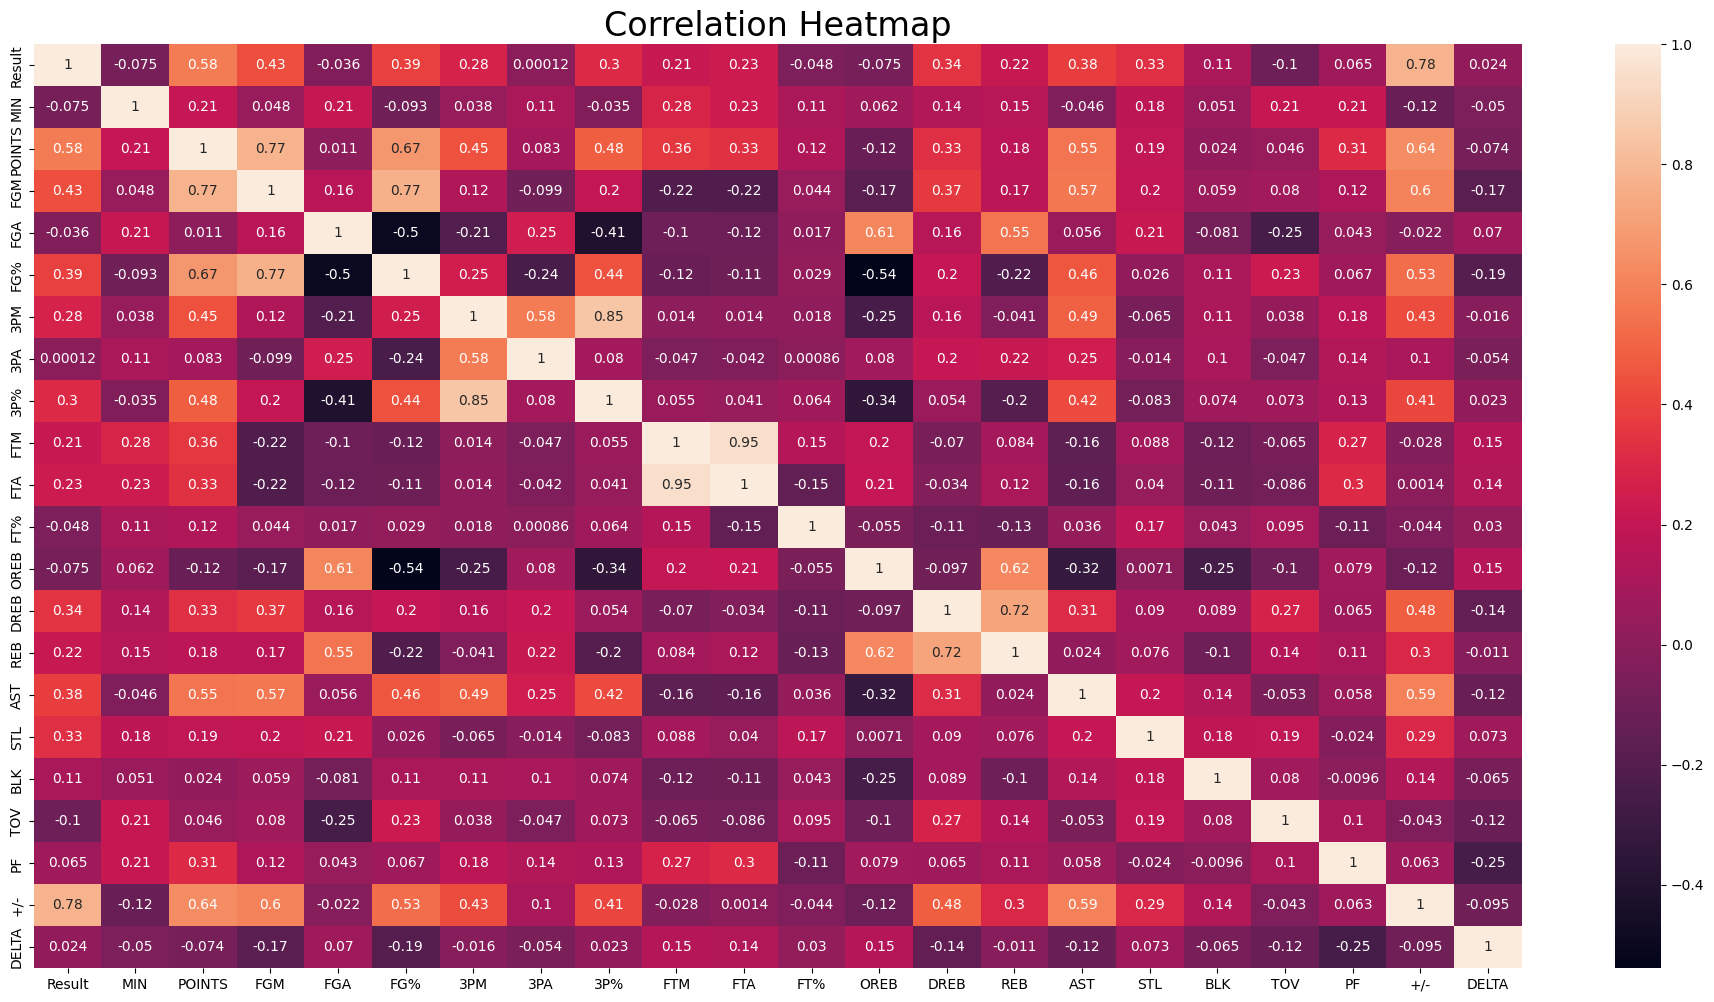

In [19]:
# importing seaborn library
import seaborn as sns

# Creating sample data for a heatmap
data = df_corr

# Creating a heatmap using Seaborn
plt.figure(figsize=(24, 12))
sns.heatmap(data, annot=True)
plt.title('Correlation Heatmap', size = 24)

# displaying map
plt.show()

##### [Q] Naturally, we should first try to observe what game stats (features) help the team towards a victory or a loss ($1$ or $0$ in the `'Result'` column). Order the correlations dataframe by the `'Result'` column.


In [20]:
#Sort by descending values and display/view the sorted table

df_corr_sorted = df_corr.sort_values(by='Result', ascending=False)

# displaying the sorted correlation matrix
df_corr_sorted

,Result,MIN,POINTS,FGM,FGA,FG%,3PM,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,PF,+/-,DELTA
Result,1.000000,-0.075488,0.575034,0.432612,-0.035753,0.386880,0.276205,0.000122,0.303570,0.212808,0.232450,-0.047695,-0.074823,0.340098,0.216745,0.376716,0.331385,0.107905,-0.103160,0.065232,0.775046,0.024431
+/-,0.775046,-0.118805,0.638127,0.601160,-0.021792,0.525421,0.425918,0.100102,0.409729,-0.028239,0.001423,-0.043511,-0.116633,0.478098,0.296742,0.594779,0.294362,0.140216,-0.042890,0.062628,1.000000,-0.094771
POINTS,0.575034,0.205407,1.000000,0.772660,0.011150,0.671907,0.446822,0.083493,0.482326,0.358861,0.334081,0.122893,-0.122107,0.329554,0.175580,0.554875,0.192245,0.023599,0.045593,0.306924,0.638127,-0.074101
FGM,0.432612,0.047877,0.772660,1.000000,0.160288,0.769739,0.123228,-0.099486,0.197949,-0.218892,-0.217540,0.044170,-0.173898,0.367641,0.169707,0.566493,0.196000,0.059442,0.080031,0.118434,0.601160,-0.173268
FG%,0.386880,-0.092809,0.671907,0.769739,-0.501263,1.000000,0.250006,-0.239107,0.443555,-0.121820,-0.109766,0.028788,-0.539124,0.200536,-0.215938,0.457366,0.025679,0.110491,0.226131,0.067450,0.525421,-0.190471
AST,0.376716,-0.045692,0.554875,0.566493,0.055739,0.457366,0.485640,0.247257,0.418060,-0.164812,-0.159510,0.036187,-0.318082,0.309659,0.023773,1.000000,0.204839,0.136542,-0.053276,0.058118,0.594779,-0.120945
DREB,0.340098,0.137884,0.329554,0.367641,0.157469,0.200536,0.164125,0.202491,0.054216,-0.069903,-0.033779,-0.113645,-0.097001,1.000000,0.722717,0.309659,0.089798,0.089463,0.272679,0.065060,0.478098,-0.142681
STL,0.331385,0.177722,0.192245,0.196000,0.214096,0.025679,-0.065338,-0.014395,-0.082851,0.088067,0.040370,0.172414,0.007103,0.089798,0.075880,0.204839,1.000000,0.183933,0.189536,-0.023656,0.294362,0.072629
3P%,0.303570,-0.034957,0.482326,0.197949,-0.408065,0.443555,0.848788,0.080137,1.000000,0.055455,0.041181,0.064172,-0.343140,0.054216,-0.195448,0.418060,-0.082851,0.073525,0.072501,0.129210,0.409729,0.022631
3PM,0.276205,0.038488,0.446822,0.123228,-0.208453,0.250006,1.000000,0.578110,0.848788,0.013550,0.014242,0.018406,-0.246400,0.164125,-0.041433,0.485640,-0.065338,0.109966,0.037753,0.175792,0.425918,-0.015937


##### Let's now take a look at the features closely and their definitions.

`MIN`: Minutes played

`POINTS`: Points scored by the team

`FGM`: Field goals made (shots taken that went in the basket, 3-pointers not included)

`FGA`: Field goals attempt (total shots taken, 3-pointers not included)

`FG%`: FGM divided by FGA

`3PM`: Three pointers made (3 pointers that went in)

`3PA`: Three pointers attempted (total three point shots taken)

`3P%`: 3PM/3PA

`FTM`: Free throws made

`FTA`: Free throws attempted

`FT%`: FTM/FTA

`OREB`: Offensive rebound (The team shoots the ball, does not get it
in but is able to rebound the ball back)

`DREB`: Defensive rebound (The OTHER teams shoots the ball, does not get it in and OUR team is able to rebound the ball)

`REB`: total rebounds (OREB+DREB)

`AST`: Assists

`STL`: Steals

`BLK`: Blocks

`TOV`: Turnovers (how many times the team lost the ball)

`PF`: Personal Fouls

`+/-`: Can be ignored

#### Now that you have definitions of the features, go back and observe the sorted correlations table.

- The `'TOV'` feature is negatively correlated, which makes sense given by definition, the more times a team loses the ball, the lower the chance of them winning the game.

- The `'POINTS'` feature is positively correlated; the more points the team scored, the higher the chance of winning.

- Interestingly, the number of three point attempts made (`'3PA'`) has the least effect on the game's outcome (correlation close to $0$).

Continuing your observation of correlations between the features and the Result column, the correlations statistics start to make sense.

**Domain knowledge:** This is where domain knowledge comes into use. Having the background information of the dataset you are working with can significantly help in data analysis and machine learning tasks. The knowledge level required can vary depending on the challenge being solved; From intermediate (this lab) to advanced (Disease detection in chest x-rays using AI). It is always a good idea to go out of your way to gain knowledge in the domain you are working in and understand the data being used.

#### More Visualizations

##### [Q] Going back to our original dataframe (not the correlations `df`), plot a histogram of the points scored (`'POINTS'` column).

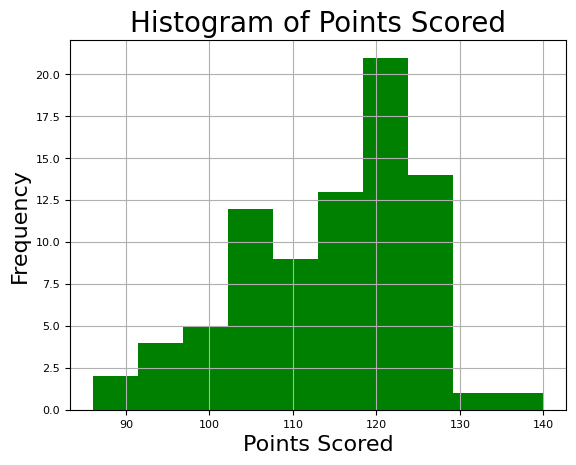

<Figure size 2000x1200 with 0 Axes>

In [21]:
# Hint: Don't set a specific bin value for this visualization, let matplotlib determine it automatically. Though this isn't always the case.
# Tip: Increase the font-size of your labels for a clearer view.

# Creating a histogram using matplotlib
plt.hist(df['POINTS'], color = 'green')
plt.title('Histogram of Points Scored', fontsize = 20)
plt.xlabel('Points Scored', fontsize = 16)
plt.ylabel('Frequency', fontsize = 16)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid(True)
plt.figure(figsize=(20, 12))

# displaying Histogram
plt.show()


##### [Q] What is the value of the points scored in a game that occur the most?

In [22]:
# checking the most occurrence for POINTS column
Highest_point = df['POINTS'].mode()[0]

print("The value of the points scored in a game that occur the most is: ", Highest_point)

The value of the points scored in a game that occur the most is:  119


##### [Q] Now plot a simple line graph of the points scored (`'POINTS'` column) over time.

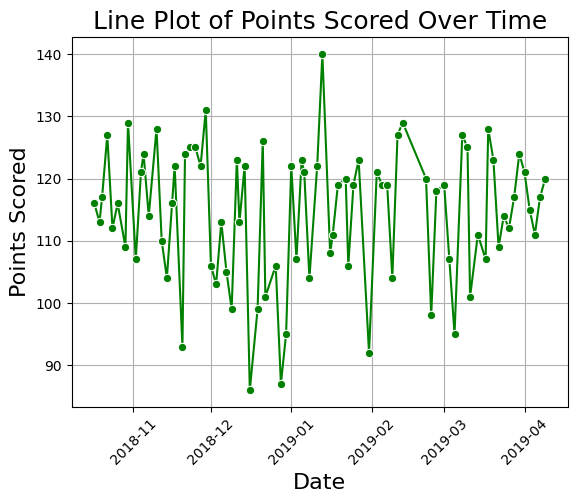

<Figure size 2000x1200 with 0 Axes>

In [23]:
# Creating a line plot using matplotlib
sns.lineplot(data=df, x='GDATE', y='POINTS', marker = 'o', color = 'green')
plt.title('Line Plot of Points Scored Over Time', size = 18)
plt.xlabel('Date', fontsize = 16)
plt.ylabel('Points Scored', fontsize = 16)
plt.xticks(rotation=45)
plt.grid(True)
plt.figure(figsize=(20, 12))
# displaying line map
plt.show()